# Энергетика в новостях: что менялось в 2022–2024 годах
**Автор: Лилия Ерофеевская**

Анализ изменения частоты и тональности шести энергетических тем в GDELT. Какие темы двигались вместе и какие изменения совпадали с крупными событиями?

## Коротко о результатах

Зелёная энергетика и климатическая политика тесно связаны по частоте упоминаний, но заметно слабее — по тональности. Вблизи 24 февраля 2022 года модель выделяет рост конфликтного и санкционного счётчиков. Вокруг COP наиболее заметный положительный сдвиг приходится на первую неделю саммита. А вот предсказательная польза тональности остаётся открытым вопросом: VAR не проходит проверку остатков.

Дальше — расчёты и ограничения каждого вывода. 

## 1. Данные и метод

Основной файл — `data/raw/gdelt_energy_daily.csv`: один день, шесть счётчиков `count` и шесть средних значений `tone`. Отдельно сохранена географическая агрегация `country_article_counts.csv`.

- **Частота** — значение тематического счётчика в выгрузке. Без исходных записей я не могу проверить, равен ли он числу уникальных статей.
- **Тональность** — средний AvgTone документов: оценка текста целиком, а не отношения читателей или автора к отдельной технологии.
- Темы пересекаются. Их нельзя складывать как независимые части новостного потока. Общего числа новостей за день нет, поэтому доли медиаповестки не рассчитаны.
- Названия «санкции и энергетика» и «конфликты и энергетика» условны: старые регулярные выражения не проверены по текстам статей. «Нефть и газ» не означает отдельный отбор новостей о России.
- [SQL в проекте](../sql/gdelt_energy_unified.sql) 


In [1]:
from pathlib import Path
import os, sys, warnings
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.environ.setdefault('MPLCONFIGDIR', str(ROOT / '.matplotlib-cache'))
warnings.filterwarnings('ignore', message='adfuller currently returns a plain tuple', category=FutureWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, Markdown
from src.analysis import (TOPICS, load_daily_data, summarize_quality, benjamini_hochberg,
    differenced_topic_correlations, event_study_hac, event_study_level_hac)
from src.advanced_models import multi_event_distributed_lag, cop_event_time_model, var_changes_by_topic
LABELS = dict(zip(TOPICS, ['Нефть и газ', 'Ядерная энергетика', 'Зелёная энергетика',
    'Климатическая политика', 'Санкции и энергетика', 'Конфликты и энергетика']))
BLUE = '#356a96'
CMAP = LinearSegmentedColormap.from_list('signed', [BLUE, '#fafafa', '#bc7132'])
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.family':'DejaVu Sans', 'font.size':10})
FIGURES, TABLES = ROOT/'reports/figures', ROOT/'reports/tables'
FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)
def note(s): display(Markdown(s))
def finish(fig, name, rect=None):
    if name in ('02_frequency','03_tone'):
        for ax in fig.axes:
            ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m.%Y'))
            ax.set_xlim(pd.Timestamp('2022-01-01'), pd.Timestamp('2024-12-31'))
    fig.tight_layout(rect=rect)
    fig.savefig(FIGURES/(name+'.png'), dpi=130, bbox_inches='tight')
    plt.show()
    plt.close(fig)
def heatmap(matrix, title, name):
    fig, ax = plt.subplots(figsize=(9,7))
    im = ax.imshow(matrix, cmap=CMAP, vmin=-1, vmax=1)
    labels = [LABELS[c.rsplit('_',1)[0]] for c in matrix.columns]
    ax.set_xticks(range(6), labels, rotation=40, ha='right')
    ax.set_yticks(range(6), labels)
    ax.grid(False)
    for i in range(6):
        for j in range(6):
            ax.text(j,i,f'{matrix.iloc[i,j]:.2f}',ha='center',va='center',
                    color='white' if abs(matrix.iloc[i,j])>.7 else '#202020')
    ax.set_title(title+'\nДневные значения, 2022–2024')
    fig.colorbar(im, ax=ax, shrink=.8, label='Pearson r')
    finish(fig,name)
data = load_daily_data(ROOT/'data/raw/gdelt_energy_daily.csv')
country = pd.read_csv(ROOT/'data/raw/country_article_counts.csv')
count_cols, tone_cols = [[t+'_'+s for t in TOPICS] for s in ('count','tone')]

### 1.1. Проверка таблиц

In [2]:
quality = summarize_quality(data)
assert quality.rows == 1096 and quality.missing_days == 0
assert quality.start_date == pd.Timestamp('2022-01-01') and quality.end_date == pd.Timestamp('2024-12-31')
assert quality.duplicate_dates == 0 and quality.missing_values == 0
assert country.country_code.notna().all() and country.country_code.is_unique
assert country.country_code.str.fullmatch('[A-Z]{2}').all()
assert (country.article_count >= 0).all() and (country.article_count % 1 == 0).all()
display(pd.Series(quality.__dict__, name='Результат').to_frame())
display(data.head(3))

,Результат
rows,1096
columns,13
start_date,2022-01-01 00:00:00
end_date,2024-12-31 00:00:00
missing_days,0
duplicate_dates,0
missing_values,0


,date,fossil_energy_count,fossil_energy_tone,nuclear_power_count,nuclear_power_tone,green_energy_count,green_energy_tone,climate_policy_count,climate_policy_tone,sanctions_energy_count,sanctions_energy_tone,conflict_energy_count,conflict_energy_tone
0,2022-01-01,4263,-0.298259,598,-1.237804,768,-0.039658,2889,-1.249151,1150,-2.343821,2628,-0.649498
1,2022-01-02,4185,-0.586491,559,-1.459046,1057,-0.917713,2928,-1.575082,644,-2.312528,2360,-1.011077
2,2022-01-03,7186,-0.757534,656,-1.548203,1322,0.283658,3422,-1.066548,1243,-2.099942,3663,-1.284629


В таблице 1 096 дней без разрывов, повторных дат и пропусков. Счётчики — неотрицательные целые числа, тональность лежит в диапазоне −100…100. Это позволяет работать с дневными рядами, но не доказывает полноту покрытия GDELT или точность тематических словарей.

### 1.2. Географические упоминания

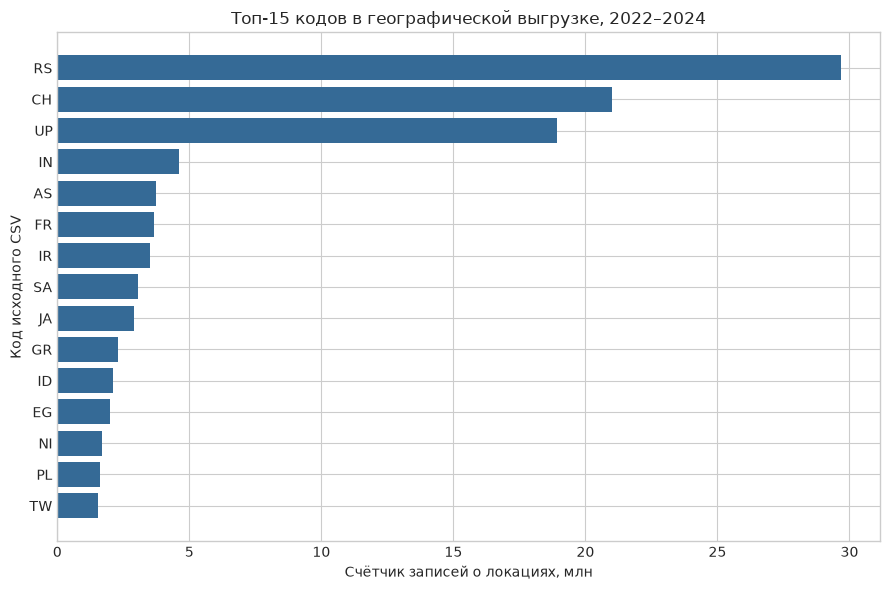

In [17]:
top = country.nlargest(15,'article_count').sort_values('article_count')
fig,ax = plt.subplots(figsize=(9,6))
ax.barh(top.country_code,top.article_count/1e6,color=BLUE)
ax.set(title='Топ-15 кодов в географической выгрузке, 2022–2024',
       xlabel='Счётчик записей о локациях, млн',ylabel='Код исходного CSV')
finish(fig,'01_geography')
leaders = country.nlargest(3,'article_count')


Самые большие счётчики: RS — 29.67 млн; CH — 21.00 млн; UP — 18.91 млн. В SQL одна статья может учитываться несколько раз при разворачивании локаций. Регулярное выражение также ограничивает набор извлекаемых записей. Поэтому не производится подмена кодов названиями стран и не сообщается результат чисел уникальных статей или географией СМИ. В H1–H4 эта таблица не используется.

## 2. Динамика
### 2.1. Как менялась частота

На графиках использовано среднее за последние 14 дней. Оно сглаживает недельный ритм и немного запаздывает. В моделях остаются исходные дневные значения.

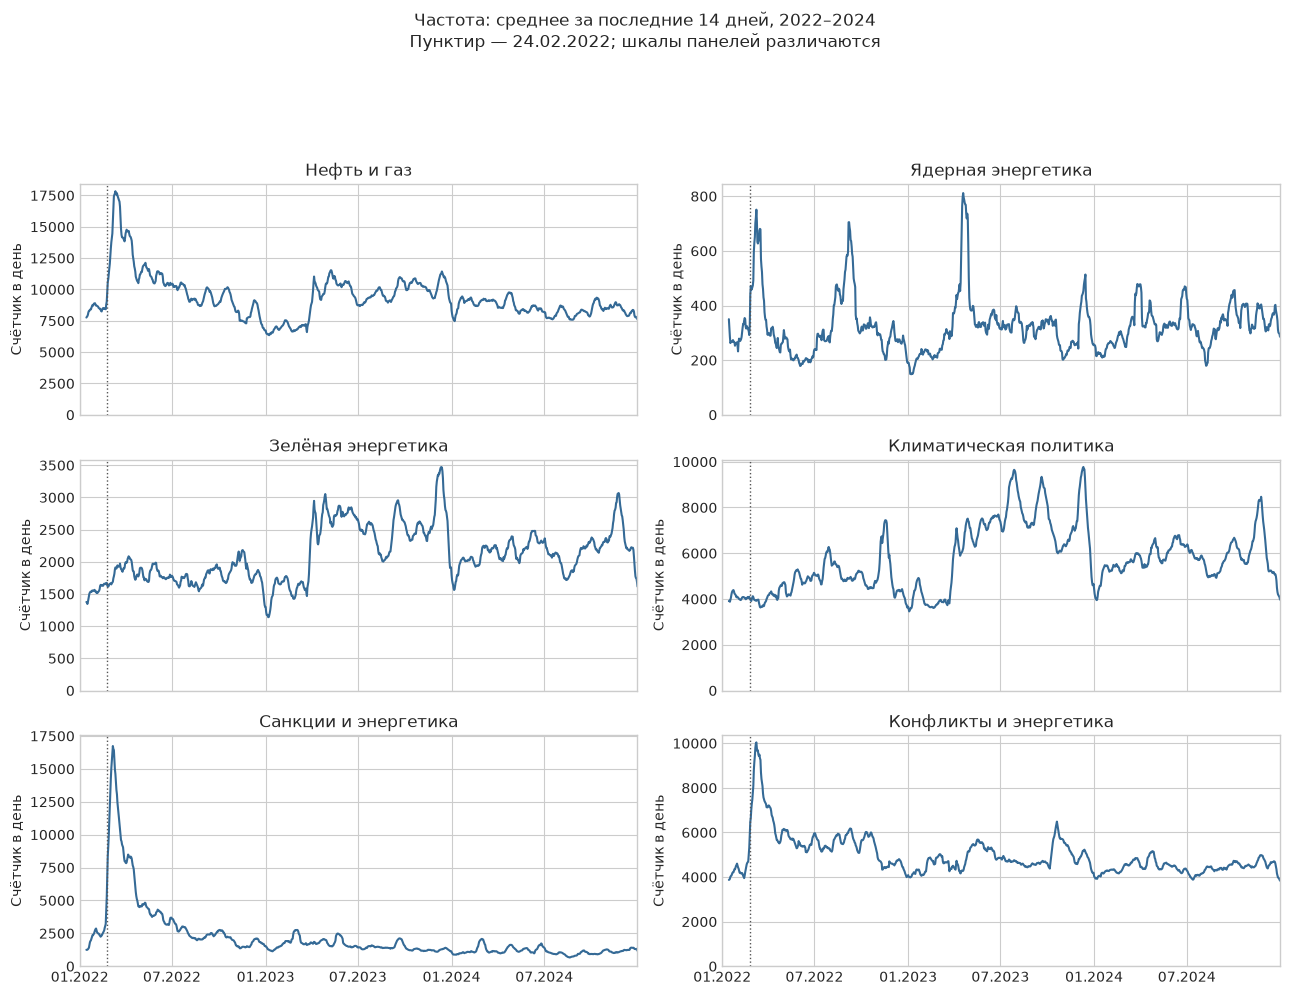

,Нефть и газ,Ядерная энергетика,Зелёная энергетика,Климатическая политика,Санкции и энергетика,Конфликты и энергетика
date,,,,,,
2022,10100.0,325.0,1757.0,4690.0,3821.0,5534.0
2023,9290.0,324.0,2359.0,6583.0,1570.0,4826.0
2024,8510.0,329.0,2166.0,5783.0,1146.0,4432.0


fossil_energy_count      -15.7
nuclear_power_count        1.1
green_energy_count        23.2
climate_policy_count      23.3
sanctions_energy_count   -70.0
conflict_energy_count    -19.9
dtype: float64

In [18]:
fig,axes = plt.subplots(3,2,figsize=(13,10),sharex=True)
for ax,t in zip(axes.flat,TOPICS):
    ax.plot(data.date,data[t+'_count'].rolling(14).mean(),color=BLUE)
    ax.axvline(pd.Timestamp('2022-02-24'),color='#555555',ls=':',lw=1)
    ax.set(title=LABELS[t],ylabel='Счётчик в день',ylim=(0,None))
fig.suptitle('Частота: среднее за последние 14 дней, 2022–2024\nПунктир — 24.02.2022; шкалы панелей различаются',y=0.99)
finish(fig,'02_frequency',rect=[0,0,1,0.91])
annual = data.groupby(data.date.dt.year)[count_cols].mean()
display(annual.rename(columns={t+'_count':LABELS[t] for t in TOPICS}).round(0))
change = (annual.loc[2024]/annual.loc[2022]-1)*100
display(change.round(1))

Средний дневной санкционный счётчик в 2024 году ниже, чем в 2022-м, на 70.0%, а счётчик нефти и газа — на 15.7%. У климатической политики максимум годового среднего приходится на 2023 год. Проведено сравнение средних за день, а не суммы: в 2024 году на один день больше. Без общего объёма новостей эти изменения нельзя назвать изменением доли внимания СМИ. На нескольких рядах видны резкие изменения около границ 2023 и 2024 годов.




### 2.2. Каким был эмоциональный фон

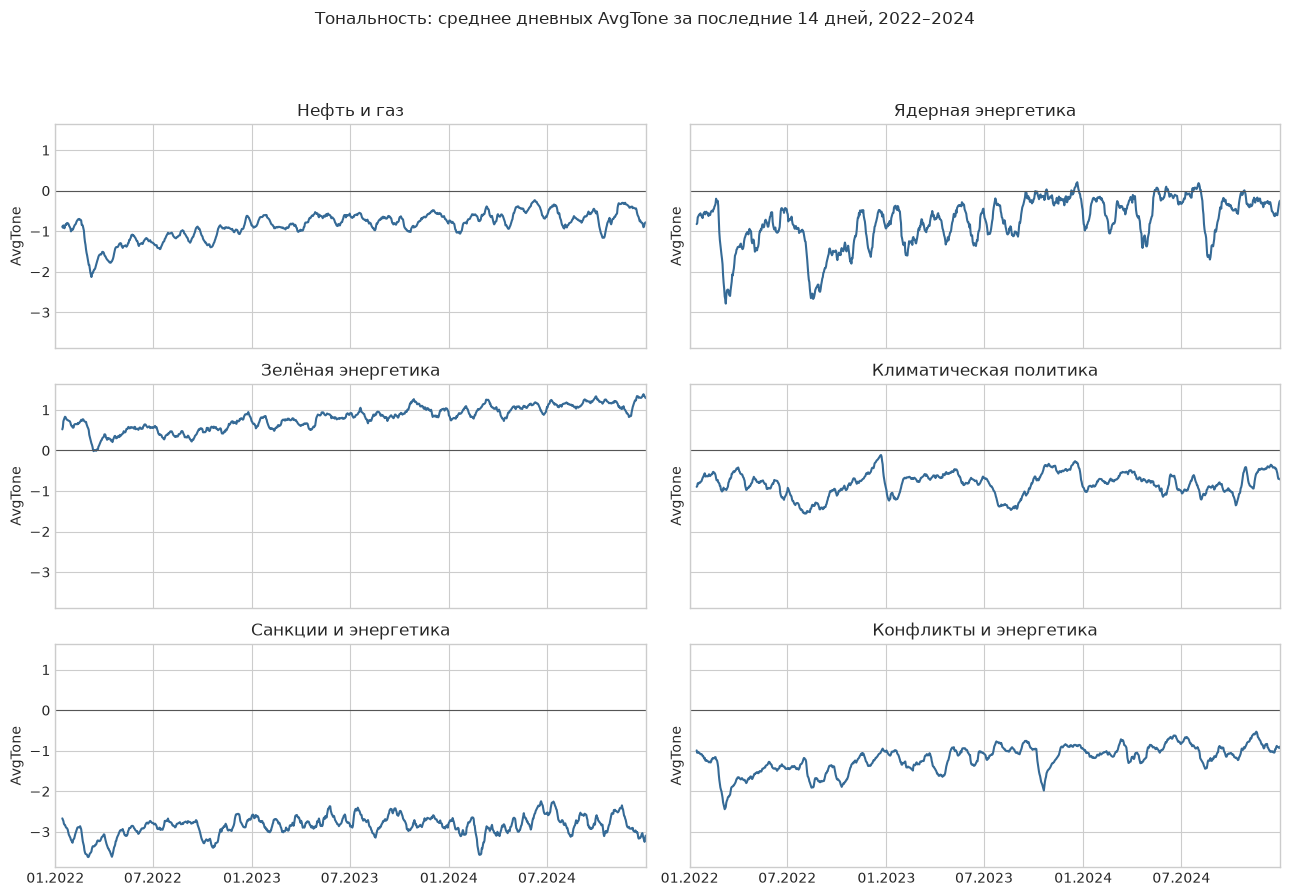

In [19]:
fig,axes = plt.subplots(3,2,figsize=(13,9),sharex=True,sharey=True)
for ax,t in zip(axes.flat,TOPICS):
    ax.plot(data.date,data[t+'_tone'].rolling(14).mean(),color=BLUE)
    ax.axhline(0,color='#555555',lw=.8)
    ax.set(title=LABELS[t],ylabel='AvgTone')
fig.suptitle('Тональность: среднее дневных AvgTone за последние 14 дней, 2022–2024',y=0.99)
finish(fig,'03_tone',rect=[0,0,1,0.94])
means = data[tone_cols].mean()


Зелёная энергетика выделяется положительным средним дневным фоном (0.80 AvgTone), санкционная тема — наиболее отрицательным (-2.85). Каждый день здесь имеет одинаковый вес. Это не среднее по всем статьям: число документов с валидным tone неизвестно. Отрицательный тон также не означает неприятие энергетики — текст может обсуждать войну, риски и потери.

## 3. Какие показатели движутся вместе
### 3.1. Heatmap частоты

Pearson r показывает линейную связь. Значения около 1 означают совместное движение, около 0 — слабую линейную связь. Диагональ всегда равна 1.

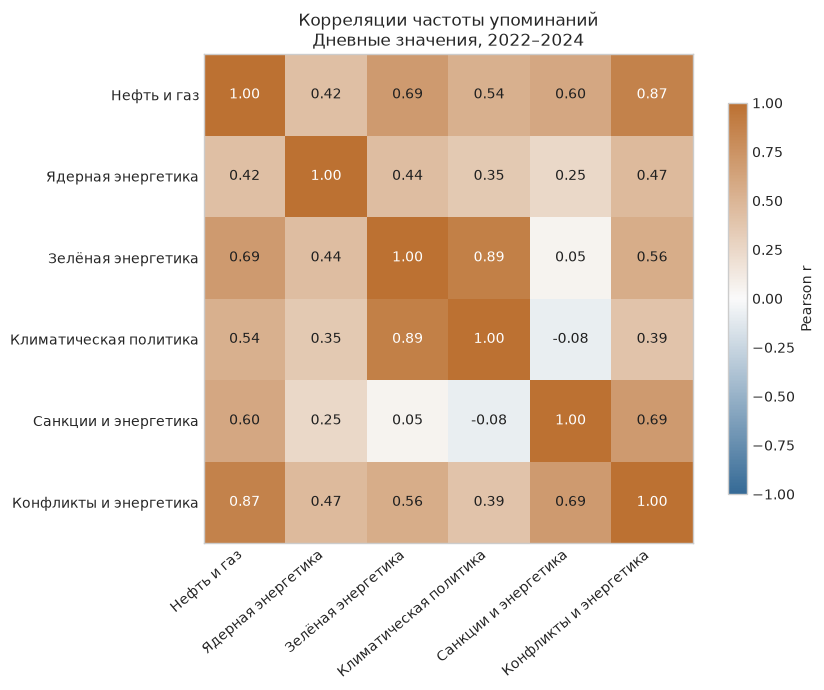

In [6]:
count_corr = data[count_cols].corr()
heatmap(count_corr,'Корреляции частоты упоминаний','04_count_heatmap')

Самая сильная пара — зелёная энергетика и климатическая политика (r = 0.89). Почти столь же тесно движутся нефть и газ и конфликтная тема (r = 0.87). У санкций и климатической политики связь слабая (r = −0.08).

Две сильные пары могут отражать общую повестку и пересечение документов. Общий тренд и недельный ритм тоже повышают корреляцию. Из этой картинки я не делаю вывод, что одна тема вызывает рост другой.

### 3.2. Heatmap тональности

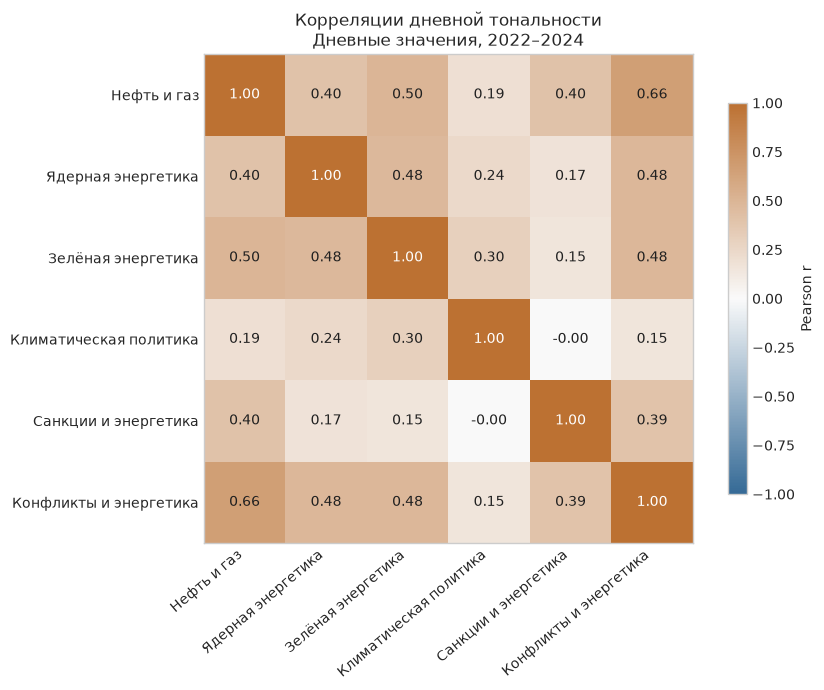

In [7]:
tone_corr = data[tone_cols].corr()
heatmap(tone_corr,'Корреляции дневной тональности','05_tone_heatmap')

Самая заметная связь снова у нефти и газа и конфликтной темы (r = 0.66). Но у зелёной энергетики и климатической политики связь тональности всего 0.30 против 0.89 для частоты. Совместный рост числа упоминаний не обязательно сопровождается одинаковым эмоциональным фоном. У климатической и санкционной тональности линейная связь практически нулевая.

### 3.3. Связаны ли изменения частоты и тона внутри одной темы

Здесь другой вопрос: сравнение изменения счётчика с изменением тона **той же темы в тот же день**. 

Использован Spearman ρ. Неопределённость приблизительно оценивается регрессией рангов с HAC-ошибками (зависимость до 14 и 28 дней). 
Поправка Benjamini–Hochberg применяется к шести темам отдельно для каждой длины HAC, чтобы снизить вероятность принять случайный результат за реальную связь. 

In [8]:
correlations = differenced_topic_correlations(data)
display(correlations.set_index('topic').rename(index=LABELS).style.format(
    {c:'{:.2e}' for c in correlations if c.startswith(('p_','q_'))},precision=3))
correlations.to_csv(TABLES/'daily_change_correlations.csv',index=False)

,spearman_rho,p_hac_14,p_hac_28,q_hac_14,q_hac_28
topic,,,,,
Климатическая политика,0.267,1.87e-24,7.85e-23,1.12e-23,4.71e-22
Зелёная энергетика,0.227,2.05e-18,9.68e-18,6.14e-18,2.91e-17
Конфликты и энергетика,0.093,7.05e-03,1.16e-02,1.41e-02,2.22e-02
Санкции и энергетика,-0.076,1.38e-02,1.48e-02,2.08e-02,2.22e-02
Ядерная энергетика,-0.009,8.30e-01,8.44e-01,8.30e-01,8.44e-01
Нефть и газ,0.008,8.10e-01,8.12e-01,8.30e-01,8.44e-01


Наиболее заметны положительные связи у климатической политики (ρ = 0.27) и зелёной энергетики (ρ = 0.23). При росте счётчиков тон чаще сдвигается в положительную сторону, но связь умеренная. У санкционной и конфликтной тем коэффициенты по модулю меньше 0.10: небольшое p-value не делает связь сильной. Для нефти и газа и ядерной энергетики убедительной одновременной связи нет. Это ещё не проверка опережения — к лагам вернемся в H4.

## 4. Проверка гипотез
### H1. Что изменилось вблизи 24 февраля 2022 года

Модель сравнивает показатели до и после 24 февраля, учитывая прежний тренд и то, что значения могут отличаться в разные дни недели. Она оценивает совпавший с этой датой сдвиг, но не доказывает, что его вызвало именно событие.

При оценке уверенности учитывается, что соседние дни могут быть похожи. Это делает поправка HAC; здесь она учитывает связь между днями на срок до двух недель.

Счётчики анализируются по шкале log(1 + count), поэтому проценты относятся к count + 1. Изменения тональности измеряются в пунктах AvgTone. 95%-й интервал показывает возможный диапазон оценки, а q-value учитывает четыре проверки H1.

Для проверки результата сравниваются окна ±30, ±60 и ±90 дней. В основном окне до события есть только 54 дня, потому что данные начинаются 1 января 2022 года. После события учитываются 61 день, включая 24 февраля.



In [9]:
rows, sensitivity = [], []
for t in ('conflict_energy','sanctions_energy'):
    for suffix in ('count','tone'):
        function = event_study_hac if suffix=='count' else event_study_level_hac
        for window in (30,60,90):
            r = function(data,t+'_'+suffix,'2022-02-24',window_days=window)
            r = {k.replace('_pct',''):v for k,v in r.items()}
            r.update(topic=LABELS[t],unit='%' if suffix=='count' else 'AvgTone',window=window)
            sensitivity.append(r)
            if window==60: rows.append(r.copy())
h1 = pd.DataFrame(rows)
h1['q_value'] = benjamini_hochberg(h1.p_value_hac)
h1_sensitivity = pd.DataFrame(sensitivity)
display(h1[['topic','unit','level_change','ci_low','ci_high','q_value','n_days']].style.format({'q_value':'{:.2e}'},precision=2))
display(h1_sensitivity.pivot(index='outcome',columns='window',values='level_change').round(2))
h1.to_csv(TABLES/'h1.csv',index=False)
h1_sensitivity.to_csv(TABLES/'h1_window_sensitivity.csv',index=False)

,topic,unit,level_change,ci_low,ci_high,q_value,n_days
0,Конфликты и энергетика,%,98.02,67.65,133.89,3.52e-15,115
1,Конфликты и энергетика,AvgTone,-0.81,-1.08,-0.54,6.30e-09,115
2,Санкции и энергетика,%,246.61,140.89,398.73,4.29e-11,115
3,Санкции и энергетика,AvgTone,-0.01,-0.37,0.36,9.77e-01,115


window,30,60,90
outcome,,,
conflict_energy_count,92.73,98.02,79.45
conflict_energy_tone,-1.03,-0.81,-0.72
sanctions_energy_count,293.38,246.61,200.75
sanctions_energy_tone,-0.19,-0.01,-0.05


 В основной спецификации конфликтный счётчик показывает сдвиг примерно +98%, санкционный — +247% относительно продолжения локального тренда. Конфликтная тональность становится отрицательнее примерно на 0.81 пункта; отдельного сдвига санкционного тона модель не выделяет.

Размер оценки зависит от окна. Поэтому я не трактую проценты как точный «эффект войны»: события конца февраля и марта перекрываются, а предыстория короткая. Сдвиг на границе также не равен среднему изменению за весь период после события.

### H2. Менялось ли внимание к ядерной и зелёной энергетике около крупных событий

В одной модели учтены все восемь событий. Для каждого события отдельно рассматриваются три периода: первая неделя (0–7 дней), вторая неделя (8–14 дней) и следующие две недели (15–30 дней).

Модель учитывает и другие закономерности: недавние значения счётчика (за день и за неделю до этого), общий тренд, различия между днями недели и сезонные изменения в течение года. Поэтому каждый коэффициент показывает, насколько счётчик в конкретном периоде отличается от ожидаемого с учётом этих факторов. Это не суммарное изменение за месяц. Проценты рассчитаны для `count + 1`, поэтому их нельзя складывать, чтобы получить общий процент за месяц.

REPowerEU датирован 18.05.2022, двенадцатый пакет санкций ЕС — 18.12.2023. [Источники дат](../reports/event_sources.md). Этот перечень — ориентиры исследования, а не полный список энергетических кризисов.

topic,green_energy,nuclear_power
event,,
12-й пакет санкций ЕС,1.78e-03,3.33e-03
Введение потолка цен,1.61e-03,7.69e-05
Взрывы Nord Stream,2.00e-09,7.64e-01
Вторжение России в Украину,1.85e-01,3.56e-05
Нападение ХАМАС,1.21e-01,5.00e-06
Объявление ОПЕК+,2.73e-02,1.31e-07
План REPowerEU,1.61e-03,2.87e-25
Эмбарго США,4.18e-02,1.14e-03


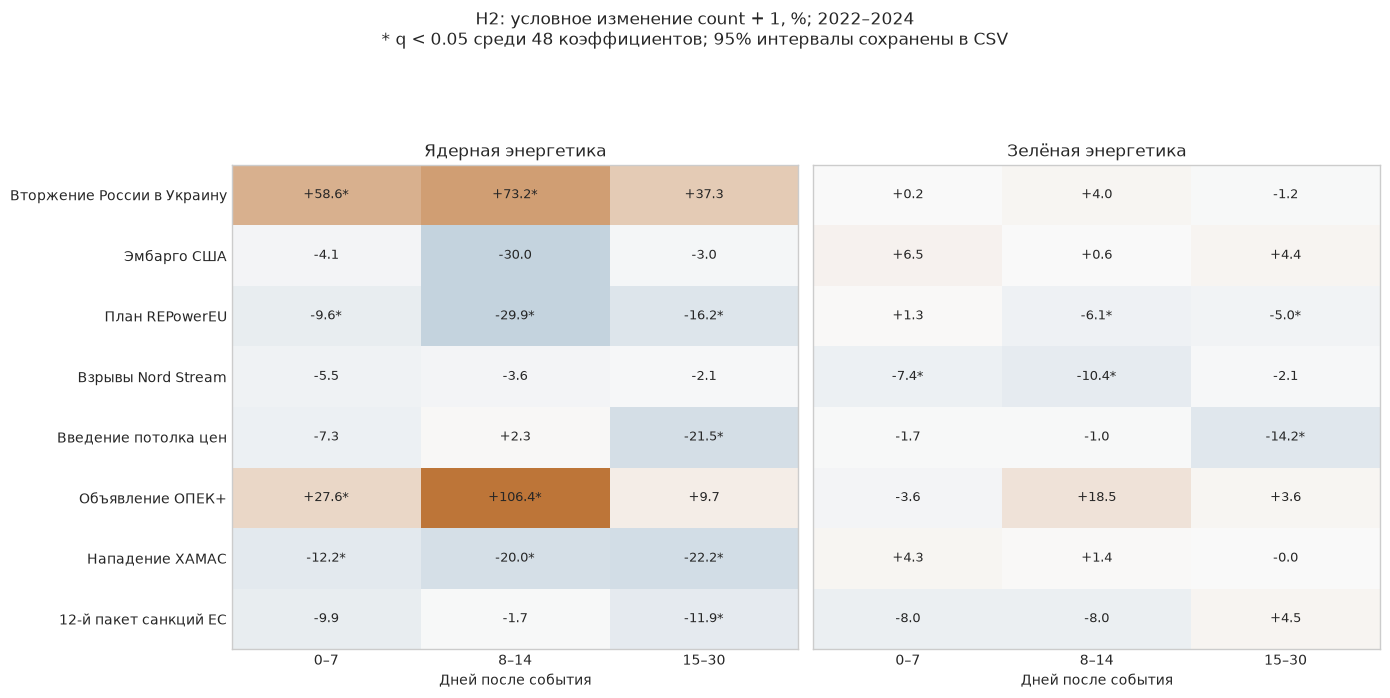

In [20]:
ENERGY_EVENTS = {
    '2022-02-24':'Вторжение России в Украину', '2022-03-08':'Эмбарго США',
    '2022-05-18':'План REPowerEU', '2022-09-26':'Взрывы Nord Stream',
    '2022-12-05':'Введение потолка цен', '2023-04-02':'Объявление ОПЕК+',
    '2023-10-07':'Нападение ХАМАС', '2023-12-18':'12-й пакет санкций ЕС'}
coefs,joints = [],[]
for t in ('nuclear_power','green_energy'):
    c,j = multi_event_distributed_lag(data,t+'_count',ENERGY_EVENTS)
    coefs.append(c.assign(topic=t)); joints.append(j.assign(topic=t))
h2,h2_joint = pd.concat(coefs,ignore_index=True),pd.concat(joints,ignore_index=True)
# Families span both topics: 48 coefficients and 16 joint tests.
h2['p_value_fdr'] = benjamini_hochberg(h2.p_value)
h2_joint['joint_p_fdr'] = benjamini_hochberg(h2_joint.joint_p_value)
display(h2_joint.pivot(index='event',columns='topic',values='joint_p_fdr').style.format('{:.2e}'))
h2.to_csv(TABLES/'h2_lag_coefficients.csv',index=False)
h2_joint.to_csv(TABLES/'h2_joint_tests.csv',index=False)
fig,axes = plt.subplots(1,2,figsize=(14,7),sharey=True)
limit = max(10,np.ceil(h2.effect_pct.abs().max()/10)*10)
for ax,t in zip(axes,('nuclear_power','green_energy')):
    part = h2.loc[h2.topic==t]
    m = part.pivot(index='event',columns='lag_bin',values='effect_pct').reindex(list(ENERGY_EVENTS.values()))[['0–7','8–14','15–30']]
    q = part.pivot(index='event',columns='lag_bin',values='p_value_fdr').reindex(m.index)[m.columns]
    ax.imshow(m,cmap=CMAP,vmin=-limit,vmax=limit,aspect='auto')
    ax.grid(False)
    ax.set_xticks(range(3),m.columns); ax.set_yticks(range(8),m.index)
    ax.set(title=LABELS[t],xlabel='Дней после события')
    for i in range(8):
        for j in range(3):
            star = '*' if q.iloc[i,j]<.05 else ''
            ax.text(j,i,f'{m.iloc[i,j]:+.1f}{star}',ha='center',va='center',fontsize=9)
fig.suptitle('H2: условное изменение count + 1, %; 2022–2024\n* q < 0.05 среди 48 коэффициентов; 95% интервалы сохранены в CSV',y=0.99)
finish(fig,'06_h2',rect=[0,0,1,0.90])


Хотя бы одно из трёх окон отличается от обычного уровня для 13 из 16 сочетаний «событие — тема». В отдельных окнах после поправки на множество проверок статистически заметны 4 положительных и 13 отрицательных отклонений. Это не показывает единого устойчивого роста интереса к альтернативной энергетике после каждого кризиса. На heatmap звёздочка отмечает результат, который остаётся заметным после поправки. События февраля и марта близки по времени, и их влияние трудно разделить. Поправка уменьшает риск случайных находок, но не устраняет смещение из-за выбора событий после знакомства с данными.

**Отдельная оговорка к H2.** Крупный ядерный коэффициент через 8–14 дней после объявления ОПЕК+ совпадает по окну с закрытием последних АЭС Германии 15.04.2023. Это событие не включено в модель отдельным контролем. Поэтому приписывать весь сдвиг решению ОПЕК+ нельзя; [источник даты закрытия](../reports/event_sources.md) позволяет проверить это пересечение.

### H3. Растёт ли климатическое внимание вокруг COP

Объединяем COP27, COP28 и COP29 по времени относительно открытия. База сравнения — дни вне пяти указанных окон, с поправкой на тренд, сезонность и лаги 1 и 7. Коэффициенты общие для трёх саммитов: они не доказывают одинаковую реакцию на каждый COP. Даты открытия — из [UNFCCC](../reports/event_sources.md).

,event_time,effect_pct,ci_low_pct,ci_high_pct,p_value,p_value_fdr
0,lead_30_15,-0.54,-5.18,4.32,8.24e-01,8.24e-01
1,lead_14_1,6.33,2.13,10.71,2.85e-03,7.12e-03
2,event_0_6,18.75,9.72,28.52,2.07e-05,1.04e-04
3,lag_7_14,4.72,-1.96,11.86,1.71e-01,2.13e-01
4,lag_15_30,-6.08,-11.07,-0.80,2.46e-02,4.09e-02


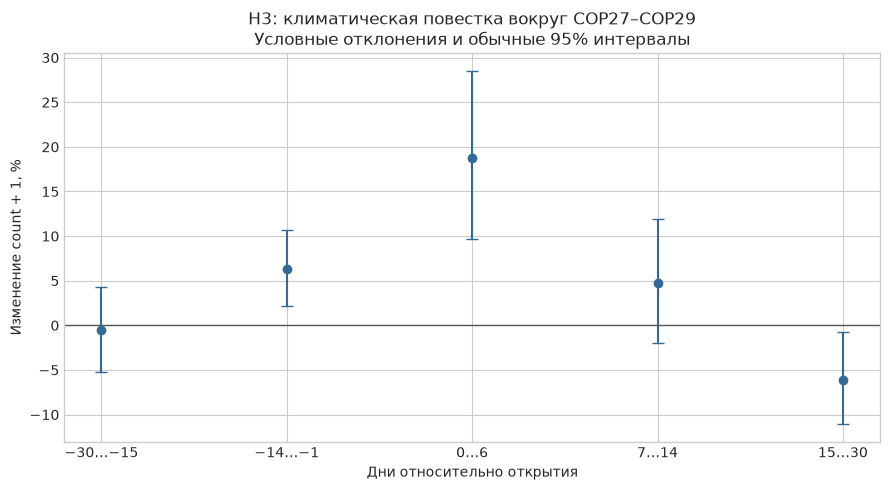

In [11]:
COP_EVENTS = {'2022-11-06':'COP27','2023-11-30':'COP28','2024-11-11':'COP29'}
h3 = cop_event_time_model(data,'climate_policy_count',COP_EVENTS)
display(h3.style.format({'p_value':'{:.2e}','p_value_fdr':'{:.2e}'},precision=2))
h3.to_csv(TABLES/'h3.csv',index=False)
fig,ax = plt.subplots(figsize=(9,5))
ax.errorbar(['−30…−15','−14…−1','0…6','7…14','15…30'],h3.effect_pct,
    yerr=[h3.effect_pct-h3.ci_low_pct,h3.ci_high_pct-h3.effect_pct],fmt='o',color=BLUE,capsize=4)
ax.axhline(0,color='#555555',lw=1)
ax.set(title='H3: климатическая повестка вокруг COP27–COP29\nУсловные отклонения и обычные 95% интервалы',
       xlabel='Дни относительно открытия',ylabel='Изменение count + 1, %')
finish(fig,'07_h3')

В две недели до открытия модель оценивает отклонение +6.3%, в первую неделю — +18.7%; обе оценки проходят FDR-поправку по пяти интервалам. Через 15–30 дней коэффициент становится отрицательным. Это согласуется с ростом внимания перед саммитом и в начале встречи, затем с его затуханием.

Но три COP — небольшое число событий, и все они проходят примерно в один сезон.Результат это описание этого периода, а не универсальным законом. Это условные коэффициенты при фиксированных прошлых значениях, а не общий прирост публикаций за саммит.

### H4. Опережает ли тональность изменение частоты

Для всех тем используем первые разности `log(1 + count)` и AvgTone. Проверим их стационарность по ADF, затем выберем лаг VAR по AIC (до 14 дней). Тест Грейнджера проверяет дополнительную информацию в прошлых изменениях тона при учёте собственных лагов частоты. Это проверка внутри выборки, а не качества прогноза на новых данных.

Отдельно проведем проверку устойчивости VAR и остаточную автокорреляцию до 28 дней. Без этой диагностики номинальная значимость может вводить в заблуждение. Автоматический переход к VECM не используется: непринятие стационарности в уровнях само по себе не доказывает интегрированность первого порядка.

In [21]:
h4 = var_changes_by_topic(data)
display(h4.set_index('topic').rename(index=LABELS).style.format(
    {c:'{:.2e}' for c in h4 if c.startswith('adf_p') or c.endswith(('_p','_q'))},precision=3))
h4.to_csv(TABLES/'h4_diagnostics.csv',index=False)


,adf_p_count_change,adf_p_tone_change,lag,tone_to_count_p,stable,whiteness_p,status,tone_to_count_q
topic,,,,,,,,
Нефть и газ,1.27e-16,4.05e-25,14,3.22e-08,True,7.72e-10,residual dependence or instability,4.82e-08
Ядерная энергетика,1.16e-17,1.98e-24,13,1.15e-03,True,6.44e-05,residual dependence or instability,1.38e-03
Зелёная энергетика,8.02e-16,4.77e-23,14,1.99e-08,True,2.22e-12,residual dependence or instability,4.82e-08
Климатическая политика,2.73e-16,1.12e-17,14,2.75e-08,True,1.70e-11,residual dependence or instability,4.82e-08
Санкции и энергетика,5.85e-17,7.83e-25,14,7.58e-02,True,1.41e-08,residual dependence or instability,7.58e-02
Конфликты и энергетика,1.84e-13,8.21e-21,14,5.44e-15,True,1.41e-09,residual dependence or instability,3.27e-14


Столбцы tone_to_count_p и tone_to_count_q отвечают на вопрос: помогают ли прошлые изменения тональности объяснить изменения частоты упоминаний, если модель уже учитывает прошлые значения самой частоты.

После поправки на одновременную проверку шести тем смотрим на tone_to_count_q:

У пяти тем q-value меньше 0.05. По принятому порогу связь выглядит статистически заметной.
У темы «Санкции и энергетика» q = 0.0758, то есть выше 0.05. Для неё убедительной связи таблица не показывает.
Это связь внутри имеющихся данных. Она сама по себе не означает, что тональность вызывает изменение частоты, и ещё не говорит, насколько хорошо модель предсказывает будущие значения.

Почему H4 не считается подтверждённой

Для модели важны два диагностических столбца:

- stable — все шесть значений True: модели устойчивы по этой проверке.
- whiteness_p — во всех шести строках значения очень малы. Проверка показывает, что ошибки модели всё ещё связаны между соседними днями. Иначе говоря, после расчёта в остатках сохраняется временной рисунок, который модель не объяснила.

Здесь важное уточнение: в столбце status написано «зависимость в остатках или неустойчивость», но stable=True во всех строках. Значит, в этих результатах проблема именно с зависимостью ошибок во времени, а не с неустойчивостью модели.

Когда такая зависимость остаётся, оценки значимости могут быть ненадёжными: модель недостаточно хорошо описывает данные, и малое q-value не снимает эту проблему. Поэтому аккуратный вывод не «тон точно предсказывает частоту», а «внутри модели есть статистически заметный сигнал, но диагностика не позволяет уверенно на него опереться».


adf_p_count_change и adf_p_tone_change — результаты проверки преобразованных рядов. Очень маленькие значения говорят, что после перехода к изменениям от дня ко дню ряды проходят тест на стационарность. lag показывает, сколько прошлых дней модель включила: здесь от 13 до 14.

Для проверки прогностической пользы нужны другая спецификация и отдельный тестовый период.




### Дополнительная проверка: помогает ли тон предсказывать частоту

Чтобы проверить прогноз, данные объединяются по полным неделям: недельное число упоминаний — сумма дневных счётчиков, недельный тон — среднее дневных значений. Модели выбираются только на неделях 2022–2023 годов; 2024 год остаётся отдельной проверкой.

Сравниваются две модели для прогноза изменения недельного `log(1 + count)`: базовая AR использует только прошлые изменения счётчика, а VAR дополнительно использует прошлые изменения тона. Число лагов выбирается на обучающем периоде. Для VAR среди вариантов выбирается модель с устойчивой динамикой и без выявленной остаточной автокорреляции; такие же проверки показаны для базовой модели.

На тестовом периоде строится прогноз на одну неделю вперёд по скользящей схеме: после каждой недели её фактические значения доступны для следующего прогноза, но параметры моделей не переобучаются. Ошибку считаем на уровне недельного `log(1 + count)`. Интервал возможного выигрыша VAR оценивается блочным bootstrap с блоками по четыре недели. 

In [22]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.stats.diagnostic import acorr_ljungbox

forecast_data = data.set_index('date')
forecast_rows = []
forecast_rng = np.random.default_rng(20260930)
for topic in TOPICS:
    count_col, tone_col = topic+'_count', topic+'_tone'
    weekly = forecast_data[[count_col, tone_col]].resample('W-SUN').agg(
        {count_col:'sum', tone_col:'mean'})
    full_week = forecast_data[count_col].resample('W-SUN').size().eq(7)
    weekly = weekly.loc[full_week]
    log_count = np.log1p(weekly[count_col])
    changes = pd.DataFrame({
        'count':log_count.diff(),
        'tone':weekly[tone_col].diff(),
    }).dropna()
    train = changes.loc[changes.index < '2024-01-01']
    test = changes.loc[changes.index >= '2024-01-01']

    ar_candidates = []
    for lag in range(1,9):
        fit = AutoReg(train['count'],lags=lag,trend='c').fit()
        white_p = float(acorr_ljungbox(
            fit.resid,lags=[12],return_df=True)['lb_pvalue'].iloc[0])
        ar_candidates.append((fit,lag,white_p))
    ar_passing = [candidate for candidate in ar_candidates if candidate[2]>=.05]
    ar_fit, ar_lag, ar_white_p = min(
        ar_passing or ar_candidates,key=lambda candidate:candidate[0].aic)

    var_candidates = []
    for lag in range(1,9):
        fit = VAR(train).fit(lag,trend='c')
        stable = bool(fit.is_stable())
        white_p = float(fit.test_whiteness(nlags=12,adjusted=True).pvalue)
        var_candidates.append((fit,lag,stable,white_p))
    var_passing = [candidate for candidate in var_candidates
                   if candidate[2] and candidate[3]>=.05]
    var_fit, var_lag, var_stable, var_white_p = min(
        var_passing or var_candidates,key=lambda candidate:candidate[0].aic)

    count_history = train['count'].to_numpy().tolist()
    pair_history = train[['count','tone']].to_numpy().tolist()
    ar_predictions, var_predictions = [],[]
    ar_params = ar_fit.params.to_numpy()
    for actual in test[['count','tone']].to_numpy():
        ar_predictions.append(ar_params[0]+sum(
            ar_params[offset+1]*count_history[-(offset+1)]
            for offset in range(ar_lag)))
        var_predictions.append(var_fit.forecast(
            np.asarray(pair_history[-var_lag:]),steps=1)[0,0])
        count_history.append(float(actual[0]))
        pair_history.append([float(actual[0]),float(actual[1])])

    actual_level = log_count.loc[test.index].to_numpy()
    previous_level = log_count.shift(1).loc[test.index].to_numpy()
    error_ar = previous_level+np.asarray(ar_predictions)-actual_level
    error_var = previous_level+np.asarray(var_predictions)-actual_level
    rmse_ar = float(np.sqrt(np.mean(error_ar**2)))
    rmse_var = float(np.sqrt(np.mean(error_var**2)))

    bootstrap_skill = []
    test_size, block_size = len(test),4
    for _ in range(2000):
        starts = forecast_rng.integers(
            0,test_size,size=int(np.ceil(test_size/block_size)))
        indices = np.concatenate([
            (start+np.arange(block_size))%test_size for start in starts
        ])[:test_size]
        sampled_ar = np.sqrt(np.mean(error_ar[indices]**2))
        sampled_var = np.sqrt(np.mean(error_var[indices]**2))
        bootstrap_skill.append(100*(1-sampled_var/sampled_ar))

    forecast_rows.append({
        'topic':topic,'train_weeks':len(train),'test_weeks':len(test),
        'ar_lag':ar_lag,'ar_whiteness_p':ar_white_p,
        'var_lag':var_lag,'var_stable':var_stable,
        'var_whiteness_p':var_white_p,
        'rmse_count_only':rmse_ar,'rmse_count_plus_tone':rmse_var,
        'rmse_skill_pct':100*(1-rmse_var/rmse_ar),
        'skill_ci_low_pct':float(np.quantile(bootstrap_skill,.025)),
        'skill_ci_high_pct':float(np.quantile(bootstrap_skill,.975)),
        'residual_checks_passed':bool(
            ar_white_p>=.05 and var_stable and var_white_p>=.05),
    })

h4_forecast = pd.DataFrame(forecast_rows)
display(h4_forecast.set_index('topic').rename(index=LABELS).style.format({
    'ar_whiteness_p':'{:.3f}','var_whiteness_p':'{:.3f}',
    'rmse_count_only':'{:.3f}','rmse_count_plus_tone':'{:.3f}',
    'rmse_skill_pct':'{:+.1f}%','skill_ci_low_pct':'{:+.1f}%',
    'skill_ci_high_pct':'{:+.1f}%',
}))
h4_forecast.to_csv(TABLES/'h4_forecast_holdout.csv',index=False)

,train_weeks,test_weeks,ar_lag,ar_whiteness_p,var_lag,var_stable,var_whiteness_p,rmse_count_only,rmse_count_plus_tone,rmse_skill_pct,skill_ci_low_pct,skill_ci_high_pct,residual_checks_passed
topic,,,,,,,,,,,,,
Нефть и газ,103,52,1,0.724,3,True,0.312,0.080,0.085,-5.1%,-16.8%,+3.7%,True
Ядерная энергетика,103,52,7,0.948,1,True,0.176,0.277,0.271,+2.1%,-7.1%,+9.4%,True
Зелёная энергетика,103,52,2,0.142,2,True,0.335,0.122,0.124,-1.7%,-7.6%,+4.2%,True
Климатическая политика,103,52,1,0.751,1,True,0.693,0.125,0.123,+1.6%,+0.1%,+3.1%,True
Санкции и энергетика,103,52,8,0.393,2,True,0.371,0.221,0.230,-3.8%,-13.1%,+4.3%,True
Конфликты и энергетика,103,52,8,0.932,6,True,0.072,0.071,0.076,-7.4%,-21.3%,+9.1%,True


 Все шесть выбранных AR- и VAR-моделей проходят заданные проверки остатков на обучающем периоде. На 52 неделях 2024 года добавление тона уменьшило RMSE только у двух тем, а у четырёх увеличило. Блочный 95%-й интервал выигрыша не включает ноль только у климатической политики; это небольшое улучшение, и поправка за сравнение шести тем здесь не применялась. Поэтому результат не подтверждает устойчивую пользу тональности для прогноза: наблюдение охватывает один тестовый год и остаётся исследовательским.

### Описательная проверка разных лагов

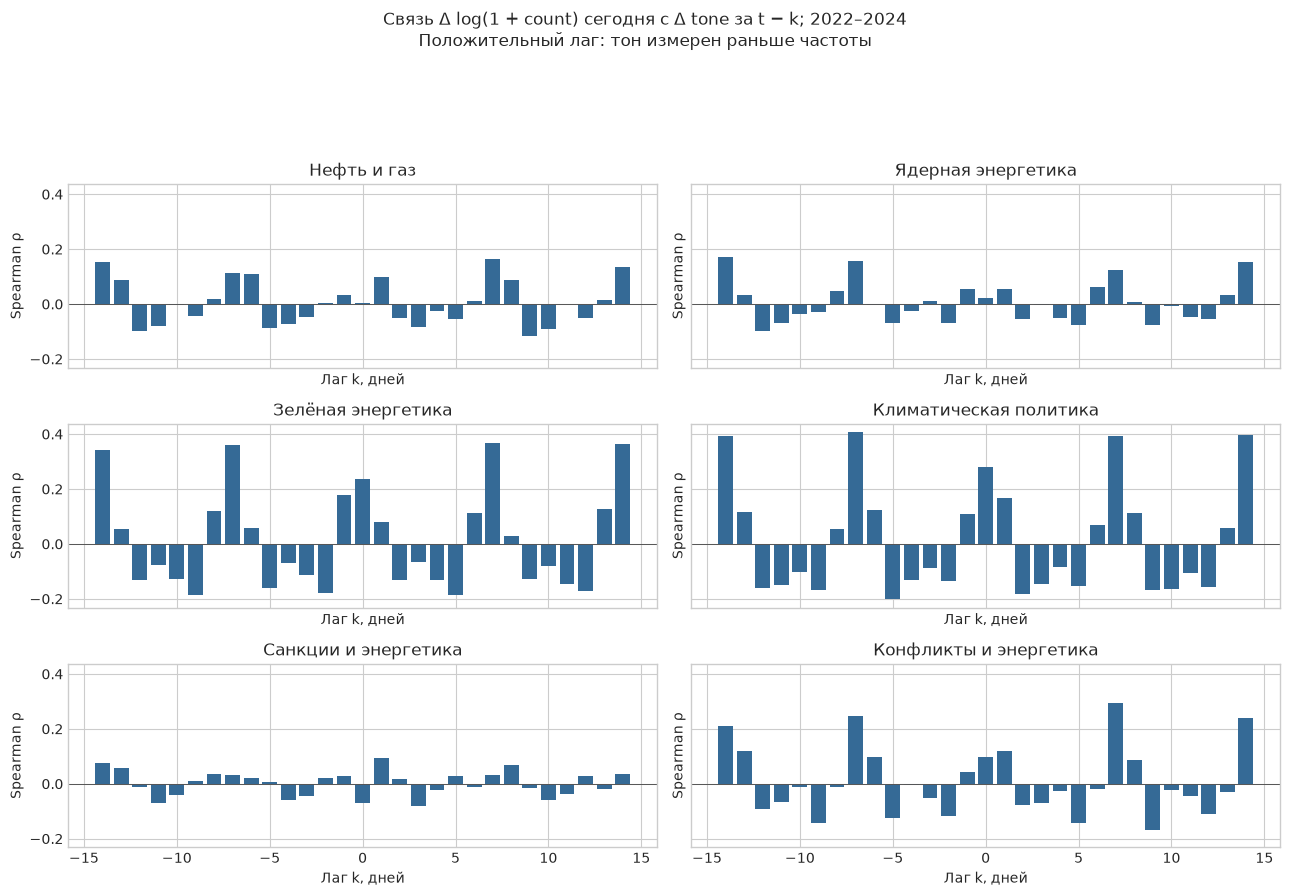

In [13]:
fig,axes = plt.subplots(3,2,figsize=(13,9),sharex=True,sharey=True)
for ax,t in zip(axes.flat,TOPICS):
    dc,dt = np.log1p(data[t+'_count']).diff(),data[t+'_tone'].diff()
    correlations_lag = [dc.corr(dt.shift(k),method='spearman') for k in range(-14,15)]
    ax.bar(range(-14,15),correlations_lag,color=BLUE)
    ax.axhline(0,color='#555555',lw=.7)
    ax.set(title=LABELS[t],ylabel='Spearman ρ',xlabel='Лаг k, дней')
fig.suptitle('Связь Δ log(1 + count) сегодня с Δ tone за t − k; 2022–2024\nПоложительный лаг: тон измерен раньше частоты',y=0.99)
finish(fig,'08_lags',rect=[0,0,1,0.90])

 У зелёной энергетики и климатической политики заметны положительные пики около −14, −7, +7 и +14 дней. Такая повторяемость в обе стороны согласуется с общим недельным ритмом, а не только с опережением частоты тоном. Столбцы справа от нуля относятся к прошлому тону, слева — к будущему. Выбор самого высокого столбца задним числом не является проверкой гипотезы: здесь нет доверительных интервалов и поправки на просмотр всех лагов. График не отменяет проблем VAR.



**Совместная повестка не равна общему тону.** Это хорошо видно у зелёной энергетики и климатической политики: корреляция частоты около 0.89, тональности — около 0.30.

**Событийные результаты неодинаковы.** В H1 выделяются рост двух счётчиков и ухудшение конфликтного тона; изменение санкционного тона неубедительно. В H2 знак и длительность отклонения зависят от события и темы. В H3 наиболее заметно окно первой недели COP.

**Предсказательная связь пока не доказана.** В H4 номинальные p-value выглядят убедительно, но диагностика остатков меняет интерпретацию. Я оставляю эту гипотезу исследовательским вопросом.

Главная граница проекта — качество исходной выборки. На готовых CSV можно воспроизвести расчёты и описать связи. Для выводов о конкретных статьях, странах или причинном влиянии событий нужны проверенные словари, исходные документы и сопоставимый контрольный ряд. Усложнение модели этого не заменяет.

### Воспроизведение и источники

Ноутбук редактируется напрямую. Чтобы выполнить все ячейки и сохранить результаты, из корня проекта запустите `python scripts/run_notebook.py`. Графики сохраняются в `reports/figures`, таблицы расчётов — в `reports/tables`; исходные CSV не меняются.

- [GDELT GKG 2.1: описание полей](https://data.gdeltproject.org/documentation/GDELT-Global_Knowledge_Graph_Codebook-V2.1.pdf).
- [SQL](../sql/gdelt_energy_unified.sql).
- [Источники дат событий](../reports/event_sources.md).